In [1]:
import pandas as pd
import numpy as np
from ScanImageTiffReader import ScanImageTiffReader
import os
import matplotlib.pyplot as plt
import scipy.signal
import tifffile
from scipy.signal import butter, lfilter,find_peaks, gaussian, convolve
from ibllib.io.video import *
import scipy.ndimage
import cv2
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
from matplotlib.animation import PillowWriter
from ScanImageTiffReader import ScanImageTiffReader
import json
from murphlib.caimage import *
from murphlib.tools import *
from murphlib.plotting import *
from murphlib.regression import *
from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score
from scipy.stats import zscore
import scipy.io
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import seaborn as sns
plt.rcParams['animation.ffmpeg_path'] = r'D:\ffmpeg\bin\ffmpeg.exe'

In [2]:
tv = np.load(r'D:\Lab_Analysis\allenCCF\template_volume_10um.npy')

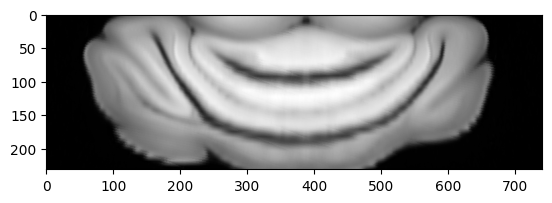

In [3]:
atlas_template = create_angled_slice(
        tv, 
        pitch_angle=15,  # 15 degrees nose down
        roll_angle=3,     # roll along ant-post axis, + rolls to the left
        slice_height=65
    )
atlas_template = atlas_template[999:1230, 199:940]
plt.imshow(atlas_template,cmap='gray')

In [4]:
agg_data = {}
behav_train_path = r'Z:\TM_Lab\Edward\Data\iblrig_data\Subjects'
ca_img_path = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m'
mouse_ids = ['A_R2', 'A_R3', 'J_L2', 'O_R2', 'R_L2']
for mouse in mouse_ids:
    mouse_path = os.path.join(ca_img_path, mouse)
    subdir = [d for d in os.listdir(mouse_path)]
    dates = [s for s in subdir if s.isdigit()]

    mouse_data = {key: {} for key in dates + ['training']}
    for date in dates:
        session_path = os.path.join(mouse_path, date)
        bhv_path = os.path.join(session_path, 'behavior')
        subdir = [d for d in os.listdir(session_path)]
        if 'arm1' in subdir:
            arm1_img_path = os.path.join(session_path, 'arm1')
            arm1_stat = get_stat_with_coord(arm1_img_path)
            arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap.npy'), allow_pickle=True)
            predictors = arm1_ridge_model[0]['predictors']
            unique_predictors = arm1_ridge_model[0]['unique_predictors']
            arm1_stat = attach_reg_model_to_stat(arm1_stat, arm1_ridge_model)
            mouse_data[date]['arm1'] = np.array(arm1_stat, dtype=object)

        if 'arm2' in subdir:
            arm2_img_path = os.path.join(session_path, 'arm2')
            arm2_stat = get_stat_with_coord(arm2_img_path)
            arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap.npy'), allow_pickle=True)
            predictors = arm2_ridge_model[0]['predictors']
            unique_predictors = arm2_ridge_model[0]['unique_predictors']
            arm2_stat = attach_reg_model_to_stat(arm2_stat, arm2_ridge_model)
            mouse_data[date]['arm2'] = np.array(arm2_stat, dtype=object)
    os.makedirs(os.path.join(mouse_path, 'figures'), exist_ok=True)
    mouse_data['training']['accuracies_vis'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_vis.npy')) 
    mouse_data['training']['accuracies_aud'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_aud.npy'))
    mouse_data['training']['num_trials'] = np.load(os.path.join(behav_train_path,mouse, 'num_trials.npy'))  
    mouse_data['training']['training_dates'] = np.load(os.path.join(behav_train_path,mouse, 'training_dates.npy'))
    psth_time_start = -0.4
    psth_time_end = 1.2
    event_preds = unique_predictors[:10]
    for predi, pred in enumerate(event_preds):
        pred_idx = [i for i, name in enumerate(predictors) if pred in name]
        for dayi, date in enumerate(dates):
            session_path = os.path.join(mouse_path, date)
            
            if 'arm1' in mouse_data[date]:
                
                stat = mouse_data[date]['arm1']
                arm1_img_path = os.path.join(session_path, 'arm1')
                arm1_table_for_img = pd.read_csv(arm1_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm1_img_meta = json.load(json_file)
                frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
                arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    

                tf_arm1_table_for_img = transform_trial_table(arm1_table_for_img)
                psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm1_dff, psth_frame_idx, zscore=False)
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_psth = zscore(mean_psth, axis=1)
                    for i, neuron in enumerate(mouse_data[date]['arm1']):
                        beta = zscore(neuron['beta'][pred_idx])
                        psth = mean_psth[i,:]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth'] = psth
            if 'arm2' in mouse_data[date]:
                
                stat = mouse_data[date]['arm2']
                arm2_img_path = os.path.join(session_path, 'arm2')
                arm2_table_for_img = pd.read_csv(arm2_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm2_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm2_img_meta = json.load(json_file)
                frame_rate_arm2 = arm2_img_meta['SI.hRoiManager.scanFrameRate']
                arm2_dff = np.load(os.path.join(arm2_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    

                tf_arm2_table_for_img = transform_trial_table(arm2_table_for_img)
                psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm2_dff, psth_frame_idx, zscore=False)
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_psth = zscore(mean_psth, axis=1)
                    for i, neuron in enumerate(mouse_data[date]['arm2']):
                        beta = zscore(neuron['beta'][pred_idx])
                        psth = mean_psth[i,:]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth'] = psth
    agg_data[mouse] = mouse_data
    

In [5]:
def rolling_average(data, window_size):
    result = np.empty_like(data, dtype=float)
    
    for i in range(len(data)):
        start_idx = max(0, i - window_size + 1)
        result[i] = np.mean(data[start_idx:i+1])
    
    return result


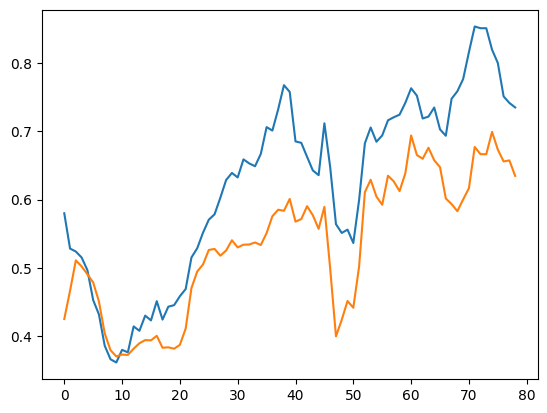

In [26]:
vis_perf = rolling_average(agg_data['A_R2']['training']['accuracies_vis'],5)
aud_perf = rolling_average(agg_data['A_R2']['training']['accuracies_aud'],5)
plt.plot(vis_perf)
plt.plot(aud_perf)

In [41]:
training_dates = agg_data['A_R2']['training']['training_dates']
ind = np.where(training_dates=='20240815')[0]
training_dates

array(['20240708', '20240709', '20240710', '20240711', '20240712',
       '20240714', '20240715', '20240716', '20240717', '20240718',
       '20240719', '20240722', '20240723', '20240724', '20240725',
       '20240729', '20240730', '20240731', '20240801', '20240802',
       '20240805', '20240806', '20240807', '20240808', '20240809',
       '20240812', '20240814', '20240816', '20240819', '20240820',
       '20240821', '20240822', '20240823', '20240826', '20240827',
       '20240828', '20240829', '20240830', '20240902', '20240903',
       '20240904', '20240905', '20240906', '20240909', '20240910',
       '20240916', '20240917', '20240918', '20240919', '20240920',
       '20240923', '20240924', '20240925', '20240926', '20240927',
       '20240930', '20241001', '20241002', '20241003', '20241004',
       '20241008', '20241010', '20241011', '20241014', '20241015',
       '20241017', '20241018', '20241021', '20241022', '20241024',
       '20241025', '20241028', '20241030', '20241031', '202411

In [7]:

event_preds = unique_predictors[:10]
for pred in event_preds:
    pred_idx = [i for i, name in enumerate(predictors) if pred in name]

    fig, axes = plt.subplots(2,2,figsize = (30,15))
    for idx in np.ndindex(axes.shape):
        row_idx, col_idx = idx
        ax = axes[idx]
        ax.imshow(atlas_template,cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0,0].set_title('Naive', fontsize = 30)
    axes[0,1].set_title('Vis expert', fontsize = 30)
    axes[1,0].set_title('Aud expert', fontsize = 30)
    axes[1,1].set_title('Double expert', fontsize = 30)
    fig.suptitle(pred, fontsize=30)
    for mouse in mouse_ids:
        mouse_data = agg_data[mouse]
        vis_perf = rolling_average(mouse_data['training']['accuracies_vis'],3)
        aud_perf = rolling_average(mouse_data['training']['accuracies_aud'],3)
        training_dates = mouse_data['training']['training_dates']
        img_dates = [i for i in mouse_data.keys() if i.isdigit()]
        
        for date in img_dates:
            training_day_num = np.where(training_dates==date)[0]
            if vis_perf[training_day_num] > 0.7 and aud_perf[training_day_num] > 0.7:
                status = 'db_expert'
                row = 1
                col = 1
            elif vis_perf[training_day_num] > 0.7:
                status = 'vis_expert'
                row = 0
                col= 1
            elif aud_perf[training_day_num] > 0.7:
                status = 'aud_expert'
                row = 1
                col = 0
            else:
                status = 'naive'
                row = 0
                col = 0
            
            if 'arm1' in mouse_data[date]:
                for i, neuron in enumerate(mouse_data[date]['arm1']):
                    #beta = zscore(neuron['beta'][pred_idx])
                    #midpoint = (len(beta)+1)//2
                    #resp_beta = np.mean(beta[midpoint:midpoint+int(0.4*15)])
                    resp_beta = np.mean(neuron['beta'][pred_idx])
                    #print(resp_beta)
                    axes[row, col].scatter(neuron['xcoord_atlas'], neuron['ycoord_atlas'], 
                      c=np.repeat(resp_beta,len(neuron['xcoord_atlas'])), 
                      cmap='coolwarm', 
                      vmin=-0.01, 
                      vmax=0.01, 
                      s=0.001,
                      alpha=0.3)
            if 'arm2' in mouse_data[date]:
                for i, neuron in enumerate(mouse_data[date]['arm2']):
                    #beta = zscore(neuron['beta'][pred_idx])
                    #midpoint = (len(beta)+1)//2
                    #resp_beta = np.mean(beta[midpoint:midpoint+int(0.4*15)])
                    resp_beta = np.mean(neuron['beta'][pred_idx])
                    #print(resp_beta)
                    axes[row, col].scatter(neuron['xcoord_atlas'], neuron['ycoord_atlas'], 
                      c=np.repeat(resp_beta,len(neuron['xcoord_atlas'])), 
                      cmap='coolwarm', 
                      vmin=-0.01, 
                      vmax=0.01, 
                      s=0.001,
                      alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs', 'beta_'+ pred + '_topo.png'),
                dpi=300,               # High resolution for publication
                bbox_inches='tight',   # Prevent clipping
                )
    plt.close(fig)
    

C:\Users\dirk\AppData\Local\Temp\ipykernel_43632\4103404872.py:26: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if vis_perf[training_day_num] > 0.7 and aud_perf[training_day_num] > 0.7:
C:\Users\dirk\AppData\Local\Temp\ipykernel_43632\4103404872.py:30: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif vis_perf[training_day_num] > 0.7:
C:\Users\dirk\AppData\Local\Temp\ipykernel_43632\4103404872.py:34: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif aud_perf[training_day_num] > 0.7:


In [8]:
event_preds = unique_predictors[:10]
for pred in event_preds:
    pred_idx = [i for i, name in enumerate(predictors) if pred in name]
    unique_pred_idx = unique_predictors.index(pred)
    fig, axes = plt.subplots(2,2,figsize = (30,15))
    for idx in np.ndindex(axes.shape):
        row_idx, col_idx = idx
        ax = axes[idx]
        ax.imshow(atlas_template,cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0,0].set_title('Naive', fontsize = 30)
    axes[0,1].set_title('Vis expert', fontsize = 30)
    axes[1,0].set_title('Aud expert', fontsize = 30)
    axes[1,1].set_title('Double expert', fontsize = 30)
    fig.suptitle(pred, fontsize=30)
    for mouse in mouse_ids:
        mouse_data = agg_data[mouse]
        vis_perf = rolling_average(mouse_data['training']['accuracies_vis'],3)
        aud_perf = rolling_average(mouse_data['training']['accuracies_aud'],3)
        training_dates = mouse_data['training']['training_dates']
        img_dates = [i for i in mouse_data.keys() if i.isdigit()]
        
        for date in img_dates:
            training_day_num = np.where(training_dates==date)[0]
            if vis_perf[training_day_num] > 0.7 and aud_perf[training_day_num] > 0.7:
                status = 'db_expert'
                row = 1
                col = 1
            elif vis_perf[training_day_num] > 0.7:
                status = 'vis_expert'
                row = 0
                col= 1
            elif aud_perf[training_day_num] > 0.7:
                status = 'aud_expert'
                row = 1
                col = 0
            else:
                status = 'naive'
                row = 0
                col = 0
            ax = axes[row,col]
            if 'arm1' in mouse_data[date]:
                stat = mouse_data[date]['arm1']
                for i, neuron in enumerate(np.array(stat)):
                    if neuron['celltype'] == 'soma':
                        continue
                    bootstrap_p = holm_bonferroni_correction(neuron['bootstrap_p_value'])
                    r2 = neuron['unique_explained_variance'][unique_pred_idx]
                    p_value = bootstrap_p[unique_pred_idx]
                    r2 = 0 if p_value > 0.05 else r2
                    color = r2  # Gray for non-significant, R² for significant
                    #color = r2
                    ax.scatter(
                        neuron['xcoord_atlas'], 
                        neuron['ycoord_atlas'], 
                        c=color if color == 'gray' else np.repeat(r2, len(neuron['xcoord_atlas'])), 
                        cmap='coolwarm', 
                        vmin=-0.02, vmax=0.02, 
                        s=0.001,
                        alpha=0.3
                    )

            # Plot arm2 neurons
            # Plot arm2 neurons
            if 'arm2' in mouse_data[date]:
                stat = mouse_data[date]['arm2']
                for i, neuron in enumerate(np.array(stat)):
                    if neuron['celltype'] == 'soma':
                        continue
                    bootstrap_p = holm_bonferroni_correction(neuron['bootstrap_p_value'])
                    r2 = neuron['unique_explained_variance'][unique_pred_idx]
                    p_value = bootstrap_p[unique_pred_idx]
                    r2 = 0 if p_value > 0.05 else r2
                    color = r2  # Gray for non-significant, R² for significant
                    #color = r2
                    ax.scatter(
                        neuron['xcoord_atlas'], 
                        neuron['ycoord_atlas'], 
                        c=color if color == 'gray' else np.repeat(r2, len(neuron['xcoord_atlas'])), 
                        cmap='coolwarm', 
                        vmin=-0.02, vmax=0.02, 
                        s=0.001,
                        alpha=0.3
                    )
    fig.tight_layout()
    fig.savefig(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs', 'unique_r2_'+ pred + '_topo.png'),
                dpi=300,               # High resolution for publication
                bbox_inches='tight',   # Prevent clipping
                )
    plt.close(fig)

C:\Users\dirk\AppData\Local\Temp\ipykernel_43632\2271701191.py:26: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if vis_perf[training_day_num] > 0.7 and aud_perf[training_day_num] > 0.7:
C:\Users\dirk\AppData\Local\Temp\ipykernel_43632\2271701191.py:30: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif vis_perf[training_day_num] > 0.7:
C:\Users\dirk\AppData\Local\Temp\ipykernel_43632\2271701191.py:34: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif aud_perf[training_day_num] > 0.7:


In [43]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'leftchoice',
 'rightchoice',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos']

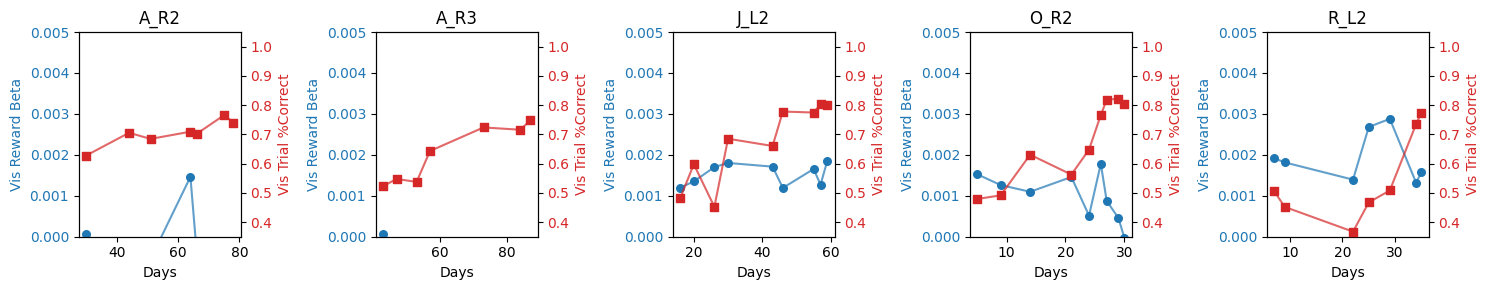

In [80]:
pred = 'vis_reward_times'
pred_idx = [i for i, name in enumerate(predictors) if pred in name]
fig, axes = plt.subplots(1, len(mouse_ids), figsize=(15, 3))
for mousei, mouse in enumerate(mouse_ids):

    mouse_data = agg_data[mouse]
    vis_perf = rolling_average(mouse_data['training']['accuracies_vis'], 3)
    aud_perf = rolling_average(mouse_data['training']['accuracies_aud'], 3)
    training_dates = mouse_data['training']['training_dates']
    img_dates = [i for i in mouse_data.keys() if i.isdigit()]

    beta_by_days = np.array([])
    vis_perf_by_days = np.array([])
    aud_perf_by_days = np.array([])
    training_day_count = np.array([])
    for date in img_dates:
        training_day_num = np.where(training_dates==date)[0]
        training_day_count = np.append(training_day_count, training_day_num)
        vis_perf_by_days = np.append(vis_perf_by_days, vis_perf[training_day_num])
        aud_perf_by_days = np.append(aud_perf_by_days, aud_perf[training_day_num])
        betas = np.array([])
        if 'arm1' in mouse_data[date]:
            for i, neuron in enumerate(mouse_data[date]['arm1']):
                resp_beta = np.mean(neuron['beta'][pred_idx])
                betas = np.append(betas, resp_beta)
        if 'arm2' in mouse_data[date]:
            for i, neuron in enumerate(mouse_data[date]['arm2']):
                resp_beta = np.mean(neuron['beta'][pred_idx])
                betas = np.append(betas, resp_beta)
        beta_by_days = np.append(beta_by_days, np.mean(betas))

    if mouse == 'A_R2':  # delete later.. 20240815 doesn't appear in training_data
        beta_by_days = beta_by_days[1:]
        
    # Plot z-scored data on primary axis
    ax1 = axes[mousei]
    color1 = 'tab:blue'
    ax1.set_xlabel('Days')
    ax1.set_ylabel('Vis Reward Beta', color=color1)
    
    # Add line
    line1 = ax1.plot(training_day_count, beta_by_days, color=color1, alpha=0.7)
    
    # Add scatter points
    scatter1 = ax1.scatter(training_day_count, beta_by_days, color=color1, s=30, zorder=3)
    
    ax1.tick_params(axis='y', labelcolor=color1)

    # Create secondary axis sharing the same x-axis
    ax2 = ax1.twinx()

    # Plot accuracy data on secondary axis
    color2 = 'tab:red'
    ax2.set_ylabel('Vis Trial %Correct', color=color2)
    
    # Add line
    line2 = ax2.plot(training_day_count, vis_perf_by_days, color=color2, alpha=0.7)
    
    # Add scatter points
    scatter2 = ax2.scatter(training_day_count, vis_perf_by_days, color=color2, s=30, zorder=3, marker='s')
    
    ax2.tick_params(axis='y', labelcolor=color2)

    # Set reasonable y-axis limits for both measures
    ax1.set_ylim(0, 0.005)  # typical range for z-scores
    ax2.set_ylim(0.35, 1.05)  # range for accuracy values

    # Add a title
    ax1.set_title(mouse)

plt.tight_layout()
plt.show()
    


Scatter plot

In [9]:
neuron['left_aud_stimOn_times_beta']

-1.554312234475219e-16

In [12]:
len(unique_predictors)

21

In [25]:
agg_data['J_L2']['20241018']['arm1'][0]['beta'].shape

(172,)

In [32]:
pred_x = 'left_aud_stimOn_times'
pred_y = 'vis_reward_times'
x_betas = []
y_betas = []
x_pred_idx = [i for i, name in enumerate(predictors) if pred_x in name]
x_pred_idx

[20, 21, 22, 23, 24]

In [ ]:
unique_predictors

In [26]:
len(predictors)

172

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


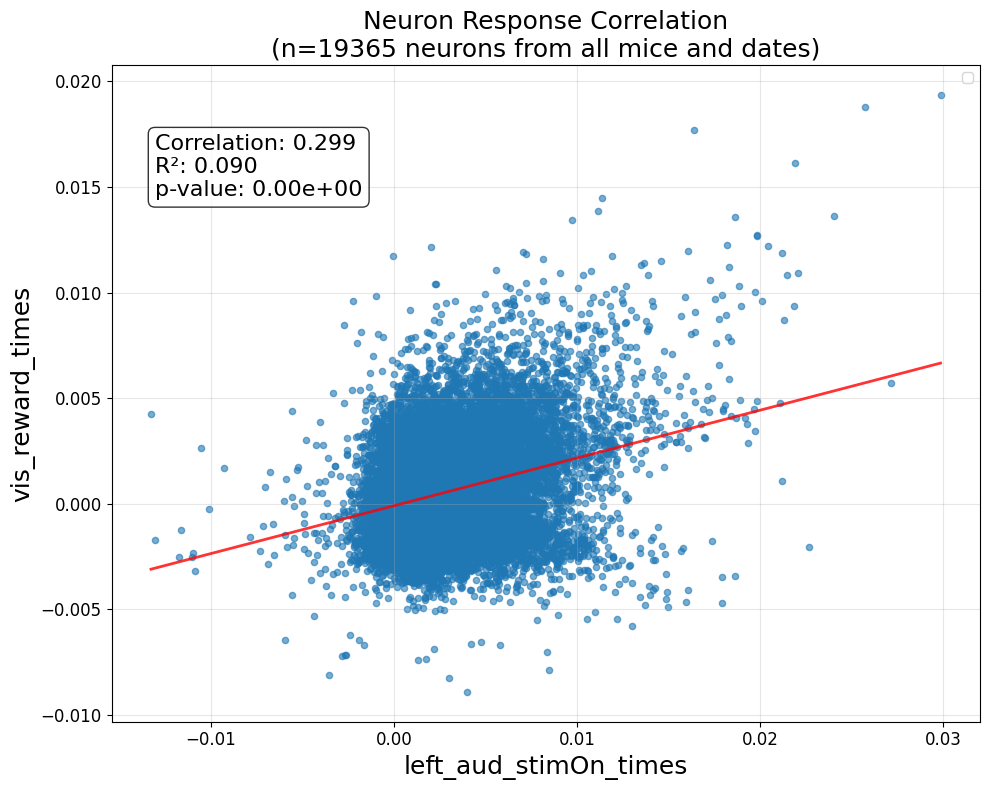

Total number of neurons: 19365
Correlation coefficient: 0.2995
Regression slope: 0.2265
Regression intercept: -0.0001
R-squared: 0.0897
P-value: 0.00e+00


In [38]:
pred_x = 'left_aud_stimOn_times'
pred_y = 'vis_reward_times'
x_betas = []
y_betas = []
x_pred_idx = [i for i, name in enumerate(predictors) if pred_x in name]
y_pred_idx = [i for i, name in enumerate(predictors) if pred_y in name]

# Loop through all mice, dates, and arms to collect beta coefficients
for mouse_id in agg_data.keys():
    # if mouse_id != 'J_L2':
    #     continue
    mouse_data = agg_data[mouse_id]
    
    # Loop through all dates (excluding 'training')
    for date in mouse_data.keys():
        #print(date)
        if date == 'training':
            continue
            
        # Check both arm1 and arm2 if they exist
        for arm in ['arm1', 'arm2']:
            if arm in mouse_data[date]:
                neurons = mouse_data[date][arm]
                
                # Loop through all neurons in this arm
                for neuron in neurons:
                    x_beta = np.mean(neuron['beta'][x_pred_idx])
                    y_beta = np.mean(neuron['beta'][y_pred_idx])
                    
                    x_betas.append(x_beta)
                    y_betas.append(y_beta)

# Convert to numpy arrays
x_betas = np.array(x_betas)
y_betas = np.array(y_betas)

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(x_betas, y_betas, alpha=0.6, s=20)
plt.xlabel(pred_x, fontsize=18)
plt.ylabel(pred_y, fontsize=18)
plt.title(f'Neuron Response Correlation\n(n={len(x_betas)} neurons from all mice and dates)', fontsize=18)
plt.grid(True, alpha=0.3)

# Make tick labels bigger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Calculate regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(x_betas, y_betas)

# Plot regression line
x_range = np.linspace(np.min(x_betas), np.max(x_betas), 100)
y_pred = slope * x_range + intercept
plt.plot(x_range, y_pred, 'r-', alpha=0.8, linewidth=2, 
         #label=f'Regression line (R²={r_value**2:.3f})'
         )

# Calculate and display correlation and regression stats
correlation = np.corrcoef(x_betas, y_betas)[0, 1]
plt.text(0.05, 0.8, f'Correlation: {correlation:.3f}\nR²: {r_value**2:.3f}\np-value: {p_value:.2e}', 
         transform=plt.gca().transAxes, fontsize=16, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend()
plt.tight_layout()
plt.show()

print(f"Total number of neurons: {len(x_betas)}")
print(f"Correlation coefficient: {correlation:.4f}")
print(f"Regression slope: {slope:.4f}")
print(f"Regression intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.2e}")

Unique Explained Variance Box Plot

In [13]:

unique_explained_cvR = []
full_explained_cvR = []
# Loop through all mice, dates, and arms to collect beta coefficients
for i, pred in enumerate(unique_predictors):
    unique_explained_cvR.append([])
    for mouse_id in agg_data.keys():
        # if mouse_id != 'J_L2':
        #     continue
        mouse_data = agg_data[mouse_id]
        
        # Loop through all dates (excluding 'training')
        for date in mouse_data.keys():
            #print(date)
            if date == 'training':
                continue
                
            # Check both arm1 and arm2 if they exist
            for arm in ['arm1', 'arm2']:
                if arm in mouse_data[date]:
                    neurons = mouse_data[date][arm]
                    
                    # Loop through all neurons in this arm
                    for neuron in neurons:
                        # Check if both predictors exist for this neuron
                        unique_explained_cvR[i].append(neuron['unique_explained_variance'][i])
                        if i == 0:
                            full_explained_cvR.append(neuron['explained_variance'])

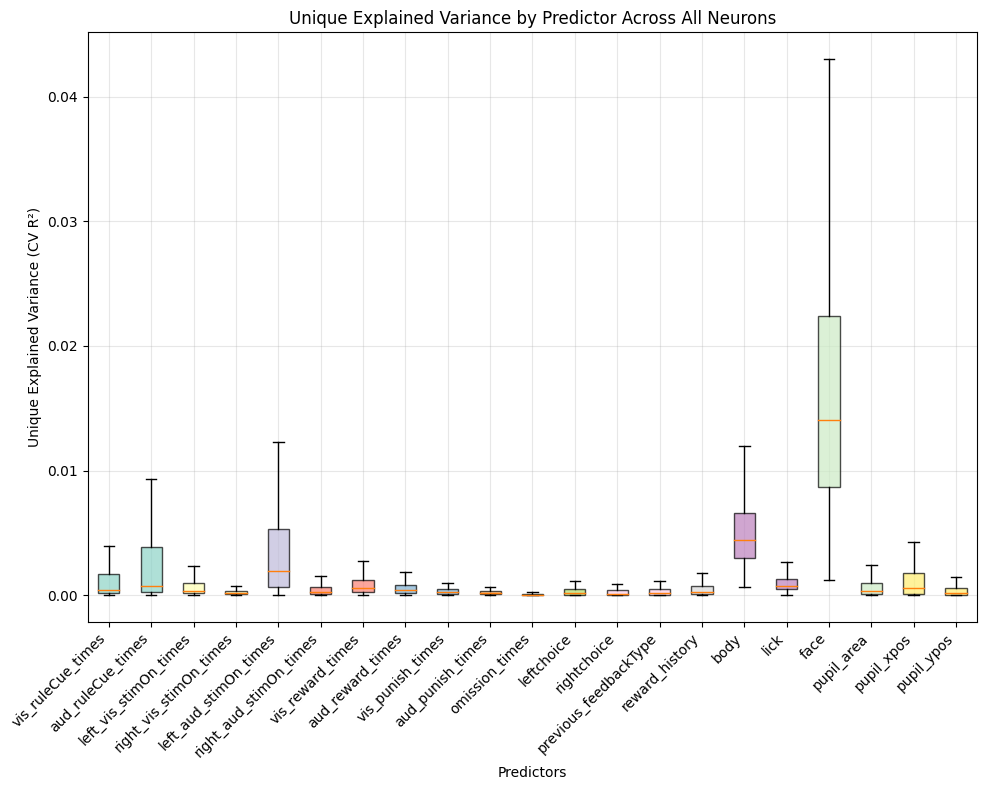

In [21]:
plt.figure(figsize=(10, 8))

# Create box plot with unique explained variance for each predictor
box_data = [unique_explained_cvR[i] for i in range(len(unique_predictors))]
bp = plt.boxplot(box_data, labels=unique_predictors, patch_artist=True, showfliers=False)

# Customize the plot
plt.xlabel('Predictors')
plt.ylabel('Unique Explained Variance (CV R²)')
plt.title('Unique Explained Variance by Predictor Across All Neurons')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Color the boxes for better visualization
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_predictors)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.tight_layout()
plt.show()

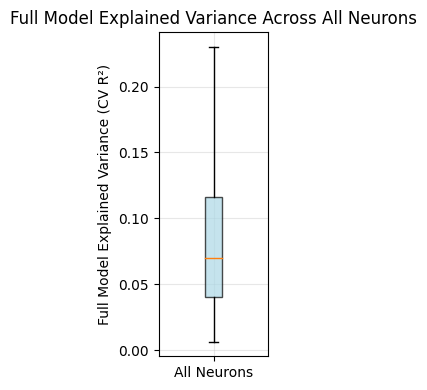

In [20]:
plt.figure(figsize=(2, 4))

# Create box plot with full explained variance for all neurons
bp = plt.boxplot([full_explained_cvR], patch_artist=True, showfliers=False)

# Customize the plot
plt.ylabel('Full Model Explained Variance (CV R²)')
plt.title('Full Model Explained Variance Across All Neurons')
plt.xticks([1], ['All Neurons'])
plt.grid(True, alpha=0.3)

# Color the box
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)

plt.tight_layout()
plt.show()
